---
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

# El balance de materia

En cualquier empresa quesera, con independencia de su tamaño, una de las primeras y más básicas cosas a realizar es un análisis del balance global de la elaboración quesera. Para un período determinado, que como primera aproximación, puede ser anual, se trata de conocer el balance entre la leche comprada y el queso producido, tanto en materia grasa como en proteína. Dado que toda la materia que no esté en el queso no puede ser vendida, no recuperaremos el coste de materia de las pérdidas (el suero de quesería ya no es un ingreso por venta; en la actualidad, en la mayor parte de los casos el suero es recogido a valor cero por las empresas que se encargan del secado de suero, con el valor del transporte como elemento de negociación).

En nuestro ejemplo, los datos que vamos a utilizar están registrados en ficheros de datos en formato `CSV`, que incluyen las entradas de leche en fábrica, los movimientos de leche dentro de la fábrica hasta su envío a fabricación, y las analíticas de la leche y el queso, así como alguna analítica adicional del proceso.

Analizaremos el conjunto de datos con `python`y Excel, siguiendo nuestra línea de trabajo.

## Caso de una fabricación sencilla de un tipo de leche

 Comenzaremos con el caso más simple, en el que se utiliza un solo tipo de leche, que no se estandariza en MG ni en MP, y se envía a fabricación después de pasteurización.

En esta quesería, se recibe leche de vaca de domingo a jueves, y se fabrica de lunes a viernes. De lunes a jueves se fabrican unos 5000 L de manera bastante regular, y los viernes se fabrica el resto de leche para que el stock quede a cero el fin de semana.

Los movimientos diarios de compra de leche y de envío a fabricación se recogen en un fichero csv organizado según los principios de *tidy data*.

La leche se recibe en una cisterna, se pesa en báscula, con lo que se dispone de los kilos de leche que se dan de entrada; se convierten a litros utilizando una densidad estándar de 1,030 g/ml Se hacen análisis a recepción de materia grasa y proteína en g/L.

Diariamente, se envía una cantidad fija de leche a fabricación de lunes a viernes, medida en litros, y con análisis de grasa y proteína en g/L.

No se hace control diario de existencias; la leche se recibe sobre un tanque de recepción en el que puede quedar algún resto de leche de un día para otro, no tiene por qué enviarse a fabricación cada día el 100% de la entrada. Pero la fabricación del viernes debe recoger el 100% de la leche existente, de forma que las existencias queden a cero y el lunes se empiece sin stock.

Entre las entradas y el envío a fabricación hay pérdidas de materia y simultáneamente un incremento de volumen por arrastres de agua. 

Debido a que las entradas para la fabricación semanal tienen lugar el domingo, se considera una semana de domingo a sábado (la semana ISo es lunes a domingo)

El fichero de datos que utilizaremos acumula las recepciones y fabricación de unas 25 semanas completas. Veamos el encabezado de los datos:

In [1]:
#| echo: false

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

url_datos = (
    "https://raw.githubusercontent.com/"
    "juanriera/master-queseria/master/"
    "datos/fab_queso_sim.csv"
)

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

In [2]:
df.head()

,fecha,dia_semana,semana,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,envio_fab_litros,envio_fab_grasa_g_l,envio_fab_prot_g_l,stock_cierre_litros
0,31/12/2023,Domingo,1,5297,5143,34.40,33.41,0,0.00,0.00,5143
1,01/01/2024,Lunes,1,4504,4373,37.20,31.25,5032,34.09,30.79,4516
2,02/01/2024,Martes,1,5226,5074,38.71,32.80,5017,35.96,31.10,4590
3,03/01/2024,Miércoles,1,4909,4766,38.28,31.59,5027,35.96,30.32,4356
4,04/01/2024,Jueves,1,5731,5564,36.56,31.20,5028,35.53,29.84,4920


Verificamos la información del dataframe

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha                175 non-null    object 
 1   dia_semana           175 non-null    object 
 2   semana               175 non-null    int64  
 3   entrada_kg           175 non-null    int64  
 4   entrada_litros       175 non-null    int64  
 5   entrada_grasa_g_l    175 non-null    float64
 6   entrada_prot_g_l     175 non-null    float64
 7   envio_fab_litros     175 non-null    int64  
 8   envio_fab_grasa_g_l  175 non-null    float64
 9   envio_fab_prot_g_l   175 non-null    float64
 10  stock_cierre_litros  175 non-null    int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 15.2+ KB
None


Comno vemos en la información del *dataframe*, el fichero CSV incluye la fecha del movimiento (fecha, día de las semana y numero de semana), el peso de báscula de la cisterna de entrada, la conversión en litros, y el envío a fabricación, también en litros; además. las diversas analíticas. Por comodidad y para evitar errores de medida y de muestreo (desigual reparto de la MG), la fábrica utiliza la densidad estándar de 1,030 g/ml de leche para convertir los kilos de leche en litros, como hemos dicho. Tenemos una columna con el stock diario, que no controlamos analíticamente.

Vamos a convertir la columna `fecha` a formato *datetime*, y añadimos al dataframe un campo índice con las fechas, que ordenamos por fecha. Nos interesa mantener la columna `fecha` en el *dataframe* en caso de que queramos hacer gráficos con `seaborn`.

In [4]:
# formato de fecha a la columna 'fecha'
df['fecha'] = pd.to_datetime(
    df['fecha'], 
    # dayfirst=True,      # las fechas empiezan con el dia 
    format='%d/%m/%Y',  # Formato Día/Mes/Año confirmado
    errors='coerce'     # Clave: convierte los valores que no puede leer a NaT (Not a Time)
)
# crear index con fecha
# 2. Limpiar NaT y establecer el índice
df['fecha_index'] = df['fecha']
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

Ahora calculamos los totales de materia que han entrado en la quesería y los envíos a fabricación

In [5]:
df['entrada_mg_kg'] =  df['entrada_litros'] * df['entrada_grasa_g_l']/1000
df['entrada_mp_kg'] =  df['entrada_litros'] * df['entrada_prot_g_l']/1000

df['envio_fab_mg_kg'] =  df['envio_fab_litros'] * df['envio_fab_grasa_g_l']/1000
df['envio_fab_mp_kg'] =  df['envio_fab_litros'] * df['envio_fab_prot_g_l']/1000

# Llenamos posibles valores vacíos (NaN) con 0 por seguridad antes de agrupar
columnas_a_limpiar = ['entrada_mg_kg', 'entrada_mp_kg', 'envio_fab_mg_kg', 'envio_fab_mp_kg']
df[columnas_a_limpiar] = df[columnas_a_limpiar].fillna(0)

Como las existencias de leche quedan siempre a cero en fin de semana (los viernes), podemos totalizar las entradas en fábrica por semanas, para comparar con los envíos a fabricación y hacer el balance de materia correspondiente. Creamos un nuevo dataframe para organizar esta información semanal.

In [6]:
df_semanal = (
    df.drop(columns=['dia_semana', 'fecha', 'semana']) # Eliminamos la columna con el día de la semana, la semana y la fecha diaria que no necesitamos
    .resample('W-SUN', closed='left', label='left')
    .sum()
)

# Creamos de nuevo la columna 'semana' a partir del índice de tiempo
# .isocalendar().week devuelve el número de semana estándar (ISO)
df_semanal['semana'] = df_semanal.index.isocalendar().week

# Reordenamos las columnas para que 'semana' sea la primera
# Esto facilita la vista en el CSV o en el gráfico
columnas = ['semana'] + [col for col in df_semanal.columns if col != 'semana']
df_semanal = df_semanal[columnas]

df_semanal.head()

,semana,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,envio_fab_litros,envio_fab_grasa_g_l,envio_fab_prot_g_l,stock_cierre_litros,entrada_mg_kg,entrada_mp_kg,envio_fab_mg_kg,envio_fab_mp_kg
fecha_index,,,,,,,,,,,,,
2023-12-31,52,25667,24920,185.15,160.25,25048,176.99,152.03,23525,921.87166,799.06582,886.63276,761.63926
2024-01-07,1,25446,24705,181.09,156.91,24831,172.49,149.89,24262,894.56625,775.40797,856.71688,744.51298
2024-01-14,2,25378,24638,188.18,158.11,24754,180.54,151.23,23633,926.91520,779.47564,893.94604,748.79764
2024-01-21,3,26090,25330,181.05,159.83,25454,173.30,153.08,27052,918.21702,809.65461,881.90071,779.30610
2024-01-28,4,25129,24397,181.02,165.05,24509,173.41,157.85,22601,882.91190,805.58619,849.74835,773.93186


Ahora podemos visualizar gráficamente nuestras entradas semanales de leche, tanto de litros como de grasa y proteína.

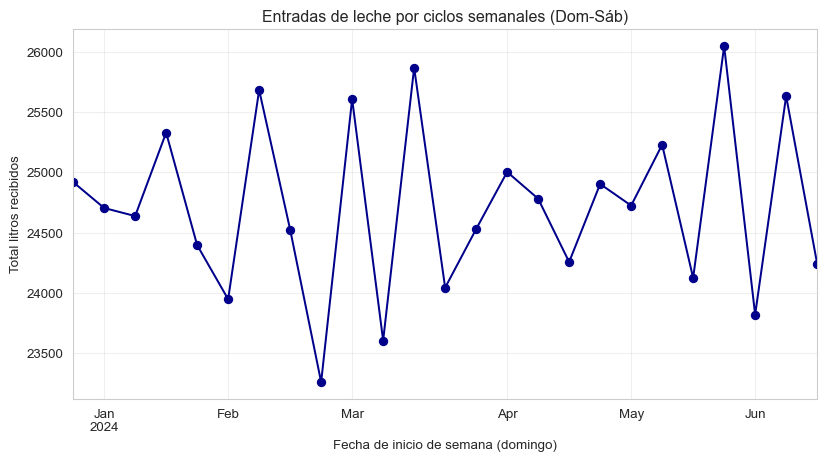

In [7]:
# Visualización
plt.figure(figsize=(10, 4))

df_semanal['entrada_litros'].plot(kind='line', marker='o', figsize=(10, 5), color='darkblue')
plt.title('Entradas de leche por ciclos semanales (Dom-Sáb)')
plt.xlabel('Fecha de inicio de semana (domingo)')
plt.ylabel('Total litros recibidos')
plt.grid(True, alpha=0.3)
plt.show()

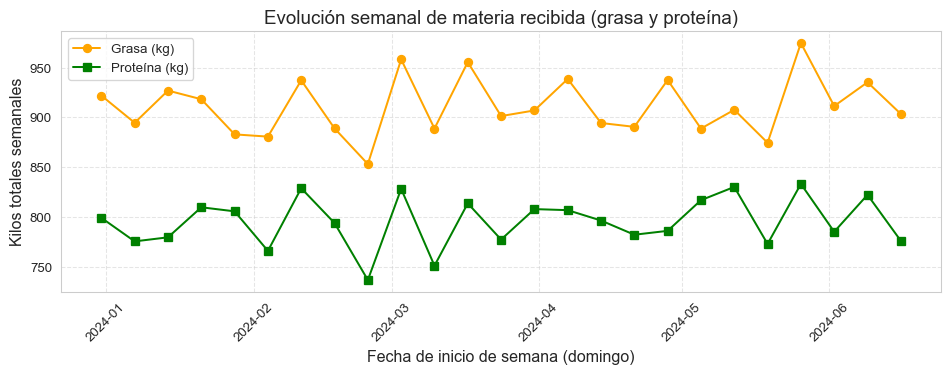

In [8]:
# Visualización de las dos líneas
plt.figure(figsize=(10, 4))

# Graficamos ambas columnas
plt.plot(df_semanal.index, df_semanal['entrada_mg_kg'], marker='o', color='orange', label='Grasa (kg)')
plt.plot(df_semanal.index, df_semanal['entrada_mp_kg'], marker='s', color='green', label='Proteína (kg)')

# Configuración del gráfico
plt.title('Evolución semanal de materia recibida (grasa y proteína)', fontsize=14)
plt.xlabel('Fecha de inicio de semana (domingo)', fontsize=12)
plt.ylabel('Kilos totales semanales', fontsize=12)
plt.legend() # Muestra la leyenda para distinguir las líneas
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

También podemos visualizar los envíos a fabricación, en litros y por componentes de materia.

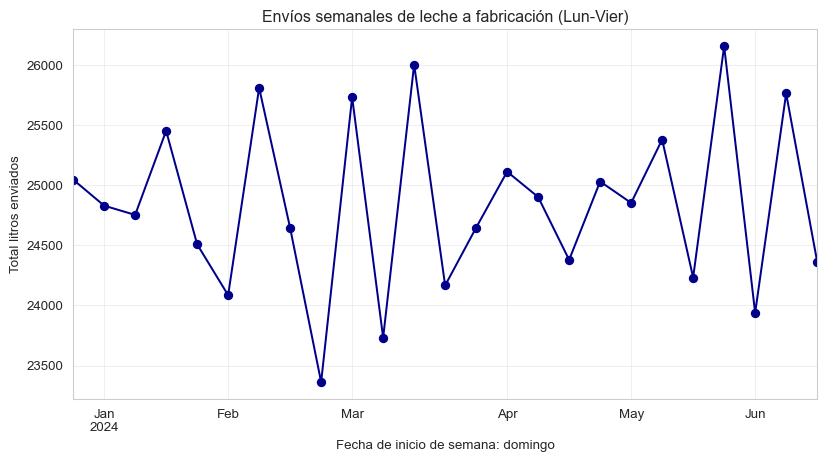

In [9]:
# Visualización
plt.figure(figsize=(10, 4))

df_semanal['envio_fab_litros'].plot(kind='line', marker='o', figsize=(10, 5), color='darkblue')
plt.title('Envíos semanales de leche a fabricación (Lun-Vier)')
plt.xlabel('Fecha de inicio de semana: domingo')
plt.ylabel('Total litros enviados')
plt.grid(True, alpha=0.3)
plt.show()

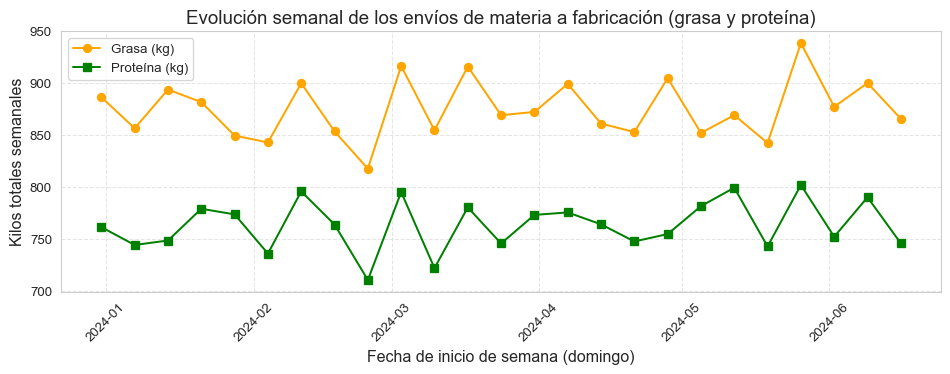

In [10]:
# Visualización de las dos líneas
plt.figure(figsize=(10, 4))

# Graficamos ambas columnas
plt.plot(df_semanal.index, df_semanal['envio_fab_mg_kg'], marker='o', color='orange', label='Grasa (kg)')
plt.plot(df_semanal.index, df_semanal['envio_fab_mp_kg'], marker='s', color='green', label='Proteína (kg)')

# Configuración del gráfico
plt.title('Evolución semanal de los envíos de materia a fabricación (grasa y proteína)', fontsize=14)
plt.xlabel('Fecha de inicio de semana (domingo)', fontsize=12)
plt.ylabel('Kilos totales semanales', fontsize=12)
plt.legend() # Muestra la leyenda para distinguir las líneas
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

---

Ahora podemos hacer el balance de materia semanal, calculando la desviación semanal entre entradas y salidas, y lo que representa esta pÉrdida en porcentaje respecto a la entrada de materia.

In [11]:
#| code-fold: false

### Balance de Materia (Salida - Entrada)
# La falta de producto queda como negativo al hacer Salida - Entrada
df_semanal['balance_liquido_mg'] = df_semanal['envio_fab_mg_kg'] - df_semanal['entrada_mg_kg']
df_semanal['balance_liquido_mp'] = df_semanal['envio_fab_mp_kg'] - df_semanal['entrada_mp_kg']

# Porcentaje de pérdida respecto a la entrada
df_semanal['perdida_mg_pct'] = df_semanal['balance_liquido_mg'] / df_semanal['envio_fab_mg_kg'] * 100
df_semanal['perdida_mp_pct'] = df_semanal['balance_liquido_mp'] / df_semanal['envio_fab_mp_kg'] * 100


Ahora que tenemos los cálculos completados, podemos exportar los datos semanales a una hoja de cñalculo, vía archivo intermedio CSV, para haver los gráficos y tablas que nos interesen, y visualizamos en `python`las diferencias de balance y de pérdidas.

In [12]:
# Exportar optimizado para Excel en español
df_semanal.to_csv(
    'datos/balance_materia_semanal.csv', 
    sep=';',       # Excel en español usa punto y coma para separar columnas
    decimal=',',   # Excel en español usa la coma para los decimales
    encoding='utf-8-sig', # El '-sig' ayuda a que Excel reconozca tildes y símbolos
    index=True     # Mantenemos el índice porque ahí está la fecha del domingo
)

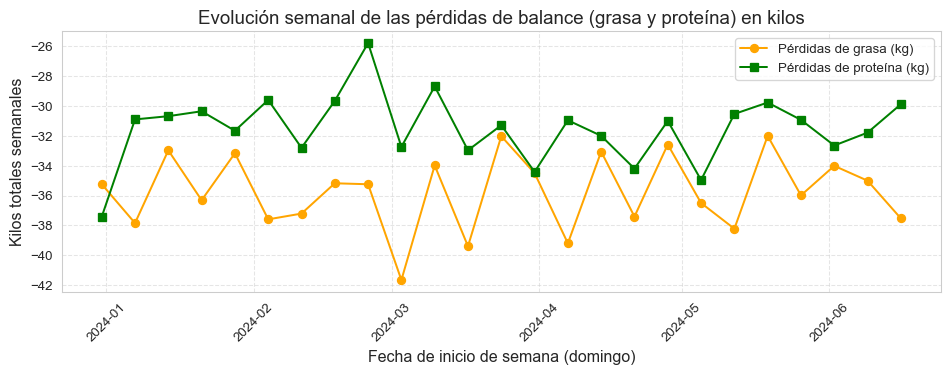

In [13]:
# Visualización de las dos líneas
plt.figure(figsize=(10, 4))

# Graficamos ambas columnas
plt.plot(df_semanal.index, df_semanal['balance_liquido_mg'], marker='o', color='orange', label='Pérdidas de grasa (kg)')
plt.plot(df_semanal.index, df_semanal['balance_liquido_mp'], marker='s', color='green', label='Pérdidas de proteína (kg)')

# Configuración del gráfico
plt.title('Evolución semanal de las pérdidas de balance (grasa y proteína) en kilos', fontsize=14)
plt.xlabel('Fecha de inicio de semana (domingo)', fontsize=12)
plt.ylabel('Kilos totales semanales', fontsize=12)
plt.legend() # Muestra la leyenda para distinguir las líneas
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

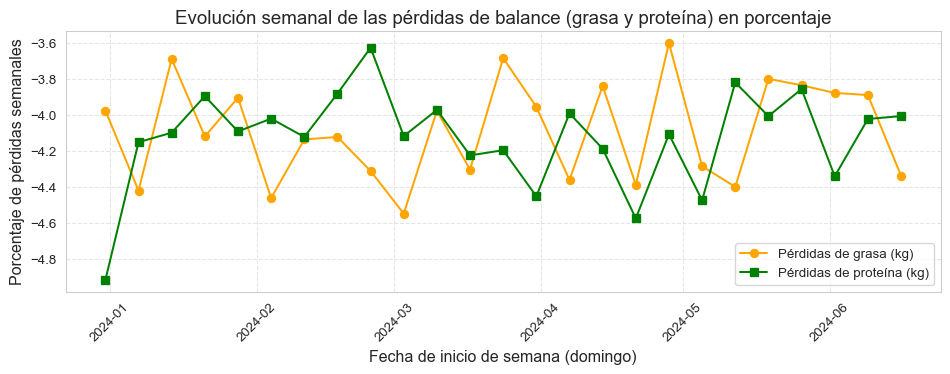

In [14]:
# Visualización de las dos líneas
plt.figure(figsize=(10, 4))

# Graficamos ambas columnas
plt.plot(df_semanal.index, df_semanal['perdida_mg_pct'], marker='o', color='orange', label='Pérdidas de grasa (kg)')
plt.plot(df_semanal.index, df_semanal['perdida_mp_pct'], marker='s', color='green', label='Pérdidas de proteína (kg)')

# Configuración del gráfico
plt.title('Evolución semanal de las pérdidas de balance (grasa y proteína) en porcentaje', fontsize=14)
plt.xlabel('Fecha de inicio de semana (domingo)', fontsize=12)
plt.ylabel('Porcentaje de pérdidas semanales', fontsize=12)
plt.legend() # Muestra la leyenda para distinguir las líneas
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Hay que hacer notar que las cantidades negativas se representan en el eje de manera que las más negativas están más abajo, y la menos negativas, más arriba, más cerca del supuesto eje cero. En caso de ser necesario, se podrían representar como valores absolutos, y esto haría una representación más ajustada a lo que se suele visualizar. Por ejemplo, utilizando el método `.abs()` para representar el valor absoluto del porcentaje de pérdida:

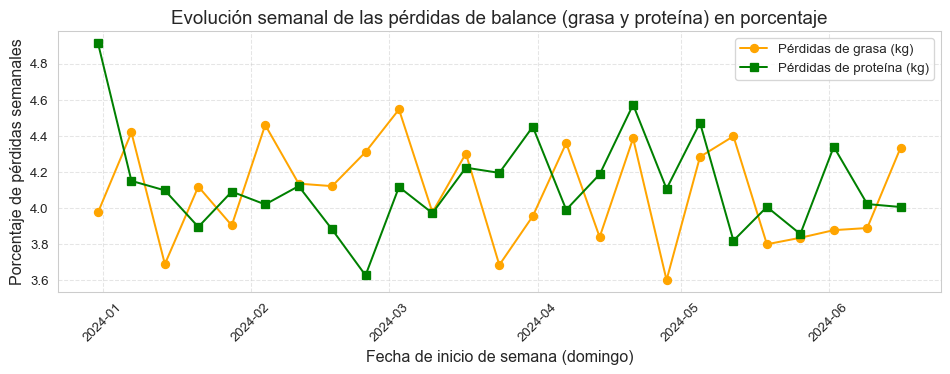

In [15]:
# Visualización de las dos líneas
plt.figure(figsize=(10, 4))

# Graficamos ambas columnas
plt.plot(df_semanal.index, df_semanal['perdida_mg_pct'].abs(), marker='o', color='orange', label='Pérdidas de grasa (kg)')
plt.plot(df_semanal.index, df_semanal['perdida_mp_pct'].abs(), marker='s', color='green', label='Pérdidas de proteína (kg)')

# Configuración del gráfico
plt.title('Evolución semanal de las pérdidas de balance (grasa y proteína) en porcentaje', fontsize=14)
plt.xlabel('Fecha de inicio de semana (domingo)', fontsize=12)
plt.ylabel('Porcentaje de pérdidas semanales', fontsize=12)
plt.legend() # Muestra la leyenda para distinguir las líneas
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Podemos completar el análisis haciendo un análisis gráfico más completo, que nos muestrela pérdida media para el período junto conuna media móvil de cuatro semanas que nos ayude a visualizar las posibles tendencias. A continuacióin, el código y la gráfica.

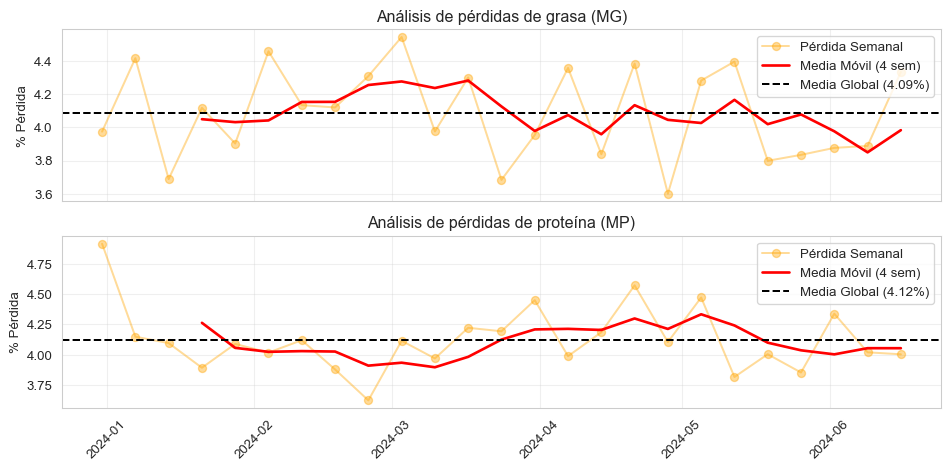

In [16]:
# 1. Preparación de datos (Ejemplo para Grasa)
mg_abs = df_semanal['perdida_mg_pct'].abs()
mg_media_global = mg_abs.mean()
mg_media_movil = mg_abs.rolling(window=4).mean()

mp_abs = df_semanal['perdida_mp_pct'].abs()
mp_media_global = mp_abs.mean()
mp_media_movil = mp_abs.rolling(window=4).mean()

# 2. Configuración de los subplots (2 filas, 1 columna)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# --- GRÁFICA 1: MATERIA GRASA (MG) ---
ax1.plot(df_semanal.index, mg_abs, marker='o', color='orange', alpha=0.4, label='Pérdida Semanal')
ax1.plot(df_semanal.index, mg_media_movil, color='red', linewidth=2, label='Media Móvil (4 sem)')
ax1.axhline(mg_media_global, color='black', linestyle='--', label=f'Media Global ({mg_media_global:.2f}%)')
ax1.set_title('Análisis de pérdidas de grasa (MG)')
ax1.set_ylabel('% Pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- GRÁFICA 2: MATERIA PROTEICA (MP) ---
ax2.plot(df_semanal.index, mp_abs, marker='o', color='orange', alpha=0.4, label='Pérdida Semanal')
ax2.plot(df_semanal.index, mp_media_movil, color='red', linewidth=2, label='Media Móvil (4 sem)')
ax2.axhline(mp_media_global, color='black', linestyle='--', label=f'Media Global ({mp_media_global:.2f}%)')
ax2.set_title('Análisis de pérdidas de proteína (MP)')
ax2.set_ylabel('% Pérdida')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Con este análisis, ahora tenemos que interpretar los resultados y establecer los planes de trabajo necesarios para comprender dónde y cómo se producen nuestras pérdidas y cómo podemos evitarlas.

## Otros casos más complejos: mezclas de leche, estandarizaciones diferentes, ventas de materia y otras situaciones

El caso que hemos visto es relativamente sencillo, para entender lo que es un balance de materia. Pero en realidad, pocas fábricas son tan sencillas. En la mayoría, a la leche de fabricación se le añade nata de suero, o se preparan leches estandarizadas en materia grasa y proteína, o bien se preparan leches de fabricación utilizando varios tipos de leche (vaca, cabra, oveja) en proporciones fijas o variables.

Lo que complica el análisis del balance es el diseño del sistema de información: en la medida en que tenemos más materias primas (nata de leche, nata de suero, retentado fresco, diferentes tipos de leche, diferentes preparaciones de leche para fabricación, etc), nos vemos obligados a llevar un control analítico sobre estas materias, además de un control de stocks. El sistema de información debe diseñarse para poder llevar este control que puede llegar a ser enormemente complejo y costoso, ya que los controles analiticos se multiplican. Pero, en todo caso, la filosofía del procedimiento es que si no queremos tener pérdidas desconocidas que no sepamos cómo atacar, nos vemos obligados a mantener un control analítico detallado de nuestras materias primas y nuestros stocks.

El uso de herramientas informáticas se hace imprescindible a medida que el diseño se hace más complejo. En estos casos, no es aconsejable diseñar un sistema sobre hojas de cálculo, sino de herramientas como `python` o `R` que permiten separar la lógica del análisis del modelo de datos, que se soporta en el sistema de información de la empresa. En estos casos, el diseño del sistema de análisis ligado al sistema de información debe ser realizado por técnicos especialistas, que diseñen un sistema que responda a las necesidades del técnico quesero para el análisis de su fabricación.

En el capítulo siguiente veremos el análisis de la siguiente etapa, la transformación quesera.